
# Sentinel-2 True Color Viewer (Microsoft Planetary Computer)

This notebook lets you:
1. Draw a polygon on a map to define your **Area of Interest (AOI)**.
2. Specify a **date or date range**.
3. Load and display a **true color (RGB)** Sentinel-2 L2A image covering the AOI.

> **Tip:** Keep your AOI modest in size for quick loading.


In [ ]:


# Required Libraries
# %pip install --quiet planetary-computer pystac-client stackstac rioxarray geopandas shapely ipyleaflet rasterio numpy matplotlib


In [7]:

import json
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import shape, mapping
import geopandas as gpd

import planetary_computer as pc
from pystac_client import Client
import stackstac
import xarray as xr

from ipyleaflet import Map, DrawControl, basemaps, basemap_to_tiles
import ipywidgets as widgets

from shapely.geometry import shape

# -------------------------
# User parameters
# -------------------------
# Set a single date 'YYYY-MM-DD' or a range 'YYYY-MM-DD/YYYY-MM-DD'
DATE = "2024-07-01/2024-07-31"   # <-- Change this as needed
MAX_CLOUD = 20                   # Cloud cover threshold (%)
COLLECTION = "sentinel-2-l2a"
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
RESOLUTION = 10                  # meters per pixel
# -------------------------

print(f"Date/Range set to: {DATE} | Cloud threshold: {MAX_CLOUD}%")


Date/Range set to: 2024-07-01/2024-07-31 | Cloud threshold: 20%



## 1) Draw your AOI

Use the polygon tool to draw your area of interest, then click **"Confirm AOI"**.  
Re-draw to replace the previous AOI if needed.


In [8]:

aoi_geojson = None  # will be populated after drawing

m = Map(
    basemap=basemaps.Esri.WorldImagery,
    center=(35.0, 33.0),  # starting view; change if you'd like
    zoom=6
)

draw_ctrl = DrawControl(
    polygon = {
        "shapeOptions": {
            "fillOpacity": 0.1,
            "weight": 2
        }
    },
    circlemarker={}
)

status = widgets.HTML("<b>Status:</b> Draw a polygon, then click <i>Confirm AOI</i>.")
confirm_btn = widgets.Button(description="Confirm AOI", button_style="success")
clear_btn = widgets.Button(description="Clear AOI")

last_geometry = {"type": "FeatureCollection", "features": []}

def handle_draw(target, action, geo_json):
    # Keep only the most recent polygon
    global last_geometry
    if geo_json and geo_json.get("geometry"):
        last_geometry = {"type": "FeatureCollection", "features": [geo_json]}
        status.value = "<b>Status:</b> Polygon captured. Click <i>Confirm AOI</i> to proceed."
    else:
        status.value = "<b>Status:</b> Invalid geometry. Please draw again."

draw_ctrl.on_draw(handle_draw)

def confirm_clicked(_):
    global aoi_geojson
    if last_geometry["features"]:
        aoi_geojson = last_geometry["features"][0]["geometry"]
        status.value = "<b>Status:</b> AOI confirmed. Proceed to the next cell to load imagery."
    else:
        status.value = "<b>Status:</b> No AOI found. Please draw a polygon first."

def clear_clicked(_):
    global last_geometry, aoi_geojson
    last_geometry = {"type": "FeatureCollection", "features": []}
    aoi_geojson = None
    m.layers = m.layers[:1]  # reset to base layer only
    status.value = "<b>Status:</b> AOI cleared. Draw a new polygon."

confirm_btn.on_click(confirm_clicked)
clear_btn.on_click(clear_clicked)

m.add_control(draw_ctrl)
widgets.VBox([m, widgets.HBox([confirm_btn, clear_btn]), status])



## 2) Search Microsoft Planetary Computer for Sentinel‑2 L2A

This cell searches for Sentinel‑2 L2A images intersecting your AOI and time filter, then picks the **least-cloudy** item.


In [9]:
if aoi_geojson is None:
    raise ValueError("AOI is not set. Go back to the map cell, draw a polygon, and click 'Confirm AOI'.")

client = Client.open(STAC_URL)

# Search WITHOUT sort / sortby (some versions don't support those args)
search = client.search(
    collections=[COLLECTION],
    intersects=aoi_geojson,
    datetime=DATE,
    query={"eo:cloud_cover": {"lt": MAX_CLOUD}},
)

# Materialize items
items = list(search.get_items())

if not items:
    raise RuntimeError(
        "No Sentinel-2 L2A items found for the AOI and date filters. "
        "Try widening the date range or increasing MAX_CLOUD."
    )

# Sort locally by eo:cloud_cover (ascending), fallback to a large number if missing
items.sort(key=lambda it: it.properties.get("eo:cloud_cover", 1e9))

# Pick the least-cloudy item
item = items[0]
signed_item = pc.sign(item)  # sign asset URLs for reading

acq_time = item.properties.get("datetime", "unknown time")
cloud = item.properties.get("eo:cloud_cover", "N/A")
print(f"Selected item: {item.id}")
print(f"Acquisition time: {acq_time} | Cloud cover: {cloud}%")


C:\Users\AshishKallikkattilKu\anaconda3\envs\cyprus\Lib\site-packages\pystac_client\item_search.py:881: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Selected item: S2B_MSIL2A_20240716T091559_R093_T34SFJ_20240716T122522
Acquisition time: 2024-07-16T09:15:59.024000Z | Cloud cover: 0.002853%



## 3) Load and display a True Color image

We read bands **B04 (Red)**, **B03 (Green)**, and **B02 (Blue)** at 10 m resolution, clip to your AOI, and apply a simple percentile stretch for display.


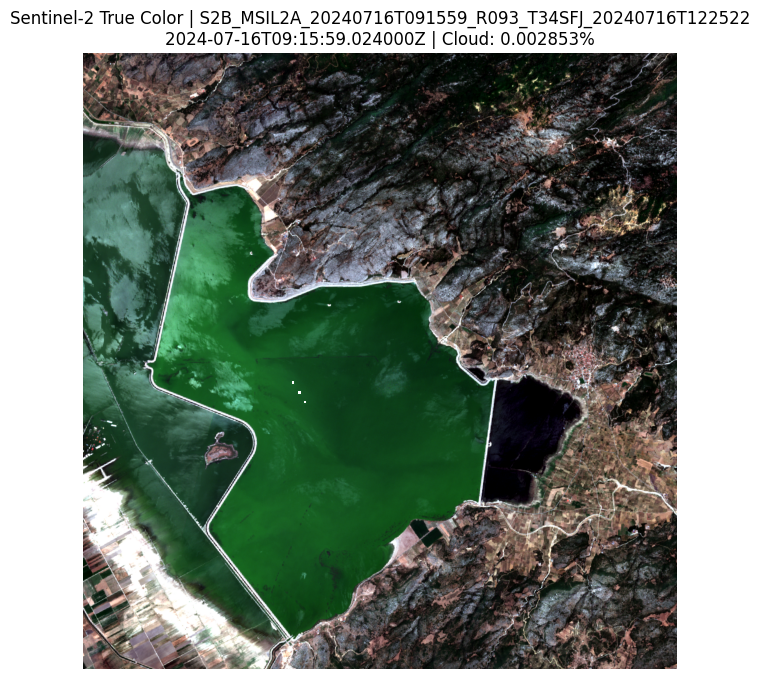

In [10]:

# AOI (fallback to item footprint if needed)
try:
    _ = aoi_geojson
except NameError:
    aoi_geojson = None
if aoi_geojson is None:
    aoi_geojson = item.geometry

aoi_geom_ll = shape(aoi_geojson)
bounds_ll = aoi_geom_ll.bounds  # (minlon, minlat, maxlon, maxlat)

# Choose a CRS (prefer native proj:epsg if present; else 3857)
epsg = (
    item.properties.get("proj:epsg")
    or item.assets["B04"].extra_fields.get("proj:epsg")
    or 3857
)

da = stackstac.stack(
    [signed_item],
    assets=["B04", "B03", "B02"],
    resolution=RESOLUTION,
    epsg=epsg,                  # from earlier (proj:epsg or 3857)
    bounds_latlon=bounds_ll,    # lon/lat bbox
    rescale=False,
    dtype="float64",            # <-- switch to float64
    fill_value=np.nan,          # OK with float64
).compute()


da = da.squeeze("time")
rgb = da.transpose("y", "x", "band").values

def percentile_stretch(img, pmin=2, pmax=98):
    import numpy as np
    out = np.zeros_like(img, dtype=np.float32)
    for b in range(img.shape[2]):
        band = img[:, :, b]
        lo, hi = np.nanpercentile(band, [pmin, pmax])
        out[:, :, b] = 0 if (not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo) else np.clip((band-lo)/(hi-lo), 0, 1)
    return out

rgb_stretched = percentile_stretch(rgb, 2, 98)

plt.figure(figsize=(8, 8))
plt.title(f"Sentinel-2 True Color | {item.id}\n{acq_time} | Cloud: {cloud}%")
plt.imshow(rgb_stretched)
plt.axis("off")
plt.show()


### (Optional) Clip precisely to your polygon

Run this cell if you want the image strictly cropped to your AOI polygon (not just the bounding box).


Applying Water Mask

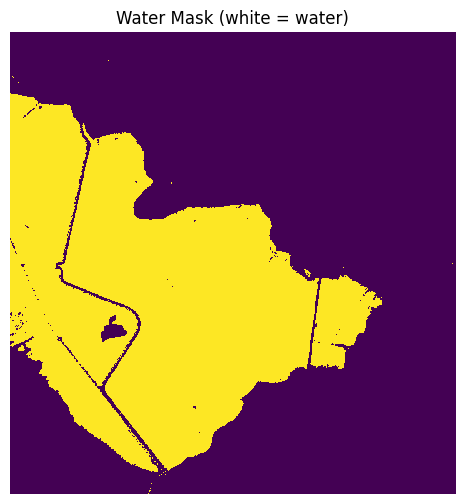

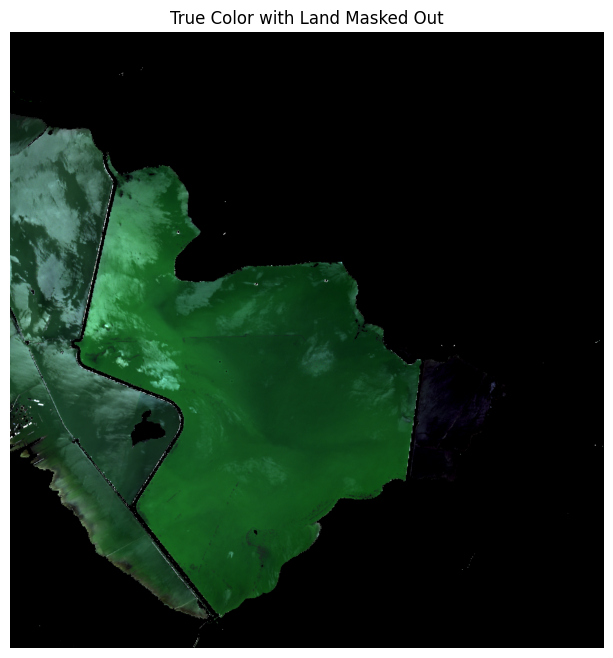

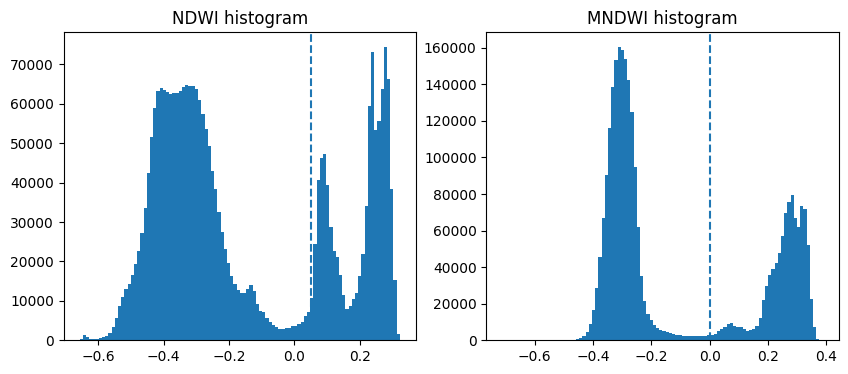

In [11]:
# ==============================
# 4) Build a Water Mask (NDWI/MNDWI) and apply it
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import shape

# ---- Parameters (tweak if needed) ----
NDWI_THRESH  = 0.05     # NDWI threshold (typical range 0.0–0.2)
MNDWI_THRESH = 0.00     # MNDWI threshold (typical range -0.1–0.1)
CLEAN_SIZE   = 0        # pixels: minimum connected-component size to keep (0 = no filtering)
FILL_VALUE   = np.float32(0.0)  # must be finite when dtype=float32
DTYPE        = "float32"        # or "float64" if you prefer

# Ensure AOI bbox in lon/lat (fallback to item footprint if AOI missing)
try:
    _ = aoi_geojson
except NameError:
    aoi_geojson = None
if aoi_geojson is None:
    aoi_geojson = item.geometry
bounds_ll = shape(aoi_geojson).bounds

# Read the bands needed for indices (B03=Green, B08=NIR, B11=SWIR1)
# We’ll resample B11 (20 m) to RESOLUTION (10 m) for convenience.
bands_da = stackstac.stack(
    [signed_item],
    assets=["B03", "B08", "B11"],
    resolution=RESOLUTION,
    epsg=epsg,                     # use CRS chosen earlier
    bounds_latlon=bounds_ll,       # crop by AOI bbox
    rescale=False,                 # raw values; we’ll normalize via indices
    dtype=DTYPE,
    fill_value=FILL_VALUE,
).compute().squeeze("time")        # -> dims: band, y, x

# Extract as arrays (y, x)
G    = bands_da.sel(band="B03").values
NIR  = bands_da.sel(band="B08").values
SWIR = bands_da.sel(band="B11").values

# Avoid divide-by-zero warnings
np.seterr(divide="ignore", invalid="ignore")

# Compute indices
ndwi  = (G - NIR) / (G + NIR)
mndwi = (G - SWIR) / (G + SWIR)

# Basic thresholds; combine (water if either indicates water)
mask_water = (ndwi > NDWI_THRESH) | (mndwi > MNDWI_THRESH)

# Optional: remove tiny speckles using scipy if available
if CLEAN_SIZE > 0:
    try:
        from scipy import ndimage as ndi
        labels, nlab = ndi.label(mask_water)
        # count sizes
        sizes = np.bincount(labels.ravel())
        small = sizes < CLEAN_SIZE
        small_mask = small[labels]
        mask_water = mask_water & (~small_mask)
    except Exception as e:
        print(f"Note: skipping CLEAN_SIZE filtering (needs scipy). Reason: {e}")

# Rebuild RGB (if you already built 'da' for RGB, you can reuse it; else compute quickly)
# We'll reuse the True Color 'da' from earlier if it exists; if not, build it now.
try:
    _ = da
    rgb = da.transpose("y", "x", "band").values
except NameError:
    da_tc = stackstac.stack(
        [signed_item], assets=["B04","B03","B02"], resolution=RESOLUTION,
        epsg=epsg, bounds_latlon=bounds_ll, rescale=False, dtype=DTYPE, fill_value=FILL_VALUE
    ).compute().squeeze("time")
    rgb = da_tc.transpose("y","x","band").values

# Simple percentile stretch for display
def percentile_stretch(img, pmin=2, pmax=98):
    out = np.zeros_like(img, dtype=np.float32)
    for b in range(img.shape[2]):
        band = img[:, :, b]
        lo, hi = np.nanpercentile(band, [pmin, pmax])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            out[:, :, b] = 0
        else:
            out[:, :, b] = np.clip((band - lo) / (hi - lo), 0, 1)
    return out

rgb_stretched = percentile_stretch(rgb, 2, 98)

# Apply water mask (set land to black)
rgb_masked = rgb_stretched.copy()
rgb_masked[~mask_water] = 0

# --- Plots ---
plt.figure(figsize=(6,6))
plt.title("Water Mask (white = water)")
plt.imshow(mask_water, interpolation="nearest")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,8))
plt.title("True Color with Land Masked Out")
plt.imshow(rgb_masked)
plt.axis("off")
plt.show()

# Optional: show histograms to tune thresholds
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(ndwi[np.isfinite(ndwi)].ravel(), bins=100)
ax[0].axvline(NDWI_THRESH, linestyle="--")
ax[0].set_title("NDWI histogram")
ax[1].hist(mndwi[np.isfinite(mndwi)].ravel(), bins=100)
ax[1].axvline(MNDWI_THRESH, linestyle="--")
ax[1].set_title("MNDWI histogram")
plt.show()


Apply Algorithm for Clear and Turbid Water Bodies

In [12]:
# ==============================
# 5) Lake type → Chlorophyll-a (OC3 for Clear, Gilerson for Turbid)
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from shapely.geometry import shape

# -------------------------
# Parameters you may tune
# -------------------------
DTYPE        = "float32"         # or "float64"
FILL_VALUE   = np.float32(0.0)   # keep finite to avoid dtype issues
RES_FOR_OC3  = RESOLUTION        # keep at 10 m; B01 (443) will be resampled from 60 m if used

# Default coefficients (placeholders; replace with your calibrated values)
# OC3-style (blue/green) polynomial: log10(Chl) = a0 + a1*X + a2*X^2 + a3*X^3 + a4*X^4
# X = log10(max(B01, B02) / B03), where B01≈443 nm (60 m), B02=490 nm, B03=560 nm
a0, a1, a2, a3, a4 = 0.2424, -2.7423, 1.8017, 0.0015, -1.2280  # <-- swap with your preferred OC3-S2 coefficients

# Gilerson-style (red–NIR) quadratic: log10(Chl) = b0 + b1*X + b2*X^2
# X = log10(B05/B04), where B05≈705 nm, B04=665 nm
b0, b1, b2 = 0.50, 2.00, 0.00  # <-- placeholders; tune to your waters

# -------------------------
# Helper: ensure AOI & bounds
# -------------------------
try:
    _ = aoi_geojson
except NameError:
    aoi_geojson = None
if aoi_geojson is None:
    aoi_geojson = item.geometry
bounds_ll = shape(aoi_geojson).bounds

# Helper: load bands as (y, x) arrays
def load_bands(asset_names, res=RESOLUTION):
    da = stackstac.stack(
        [signed_item],
        assets=asset_names,
        resolution=res,
        epsg=epsg,                  # from earlier cell (proj:epsg or 3857)
        bounds_latlon=bounds_ll,
        rescale=False,
        dtype=DTYPE,
        fill_value=FILL_VALUE,
    ).compute().squeeze("time")     # dims: band, y, x
    # Return dict of numpy arrays by band name
    return {b: da.sel(band=b).values for b in asset_names}

# OC3 (Clear) — uses B01 (443, 60 m, resampled), B02 (490), B03 (560)
def chla_oc3():
    # Load at RES_FOR_OC3 (10 m); B01 will be resampled by stackstac automatically
    bands = load_bands(["B01", "B02", "B03"], res=RES_FOR_OC3)
    B01, B02, B03 = bands["B01"], bands["B02"], bands["B03"]
    # Ratios are scale-invariant, so raw L2A scaling cancels out
    with np.errstate(divide="ignore", invalid="ignore"):
        X = np.log10(np.maximum(B01, B02) / (B03 + 1e-12))
        log_chl = a0 + a1*X + a2*X**2 + a3*X**3 + a4*X**4
        chl = 10 ** log_chl
    return chl

# Gilerson (Turbid) — uses B05 (705), B04 (665)
def chla_gilerson():
    bands = load_bands(["B05", "B04"], res=RESOLUTION)
    B05, B04 = bands["B05"], bands["B04"]
    with np.errstate(divide="ignore", invalid="ignore"):
        X = np.log10((B05 + 1e-12) / (B04 + 1e-12))
        log_chl = b0 + b1*X + b2*X**2
        chl = 10 ** log_chl
    return chl

# Ensure we have a water mask; rebuild a quick one if missing
try:
    _ = mask_water
except NameError:
    try:
        # Quick NDWI mask fallback (G & NIR only)
        bn = load_bands(["B03","B08"])
        ndwi = (bn["B03"] - bn["B08"]) / (bn["B03"] + bn["B08"] + 1e-12)
        mask_water = ndwi > 0.05
        print("Built a quick NDWI water mask (fallback).")
    except Exception as e:
        mask_water = None
        print(f"Water mask not available: {e}")

# Widgets
lake_type = widgets.ToggleButtons(
    options=[("Clear (OC3)", "clear"), ("Turbid (Gilerson)", "turbid")],
    description="Lake type:",
    button_style="",
)
run_btn = widgets.Button(description="Compute Chl-a", button_style="success")
out = widgets.Output()

def run_chl(_):
    out.clear_output()
    with out:
        if lake_type.value == "clear":
            chl = chla_oc3()
            algo_name = "OC3 (blue/green)"
        else:
            chl = chla_gilerson()
            algo_name = "Gilerson (red–NIR)"

        # Mask land (if we have a water mask)
        if mask_water is not None:
            chl_plot = np.where(mask_water, chl, np.nan)
        else:
            chl_plot = chl

        # Basic sanity clamp for display (optional)
        chl_disp = np.clip(chl_plot, 0, np.nanpercentile(chl_plot, 99.5))

        plt.figure(figsize=(8,6))
        plt.imshow(chl_disp, interpolation="nearest")
        plt.title(f"Chlorophyll-a (mg m⁻³) — {algo_name}")
        plt.colorbar(label="Chl-a (mg m⁻³)")
        plt.axis("off")
        plt.show()

        # Quick stats over water
        valid = np.isfinite(chl_plot)
        if valid.any():
            p = np.nanpercentile(chl_plot[valid], [5, 50, 95])
            print(f"Chl-a stats over water (mg m⁻³): P5={p[0]:.2f}, Median={p[1]:.2f}, P95={p[2]:.2f}")
        else:
            print("No valid water pixels found for stats.")

display(widgets.VBox([lake_type, run_btn, out]))
run_btn.on_click(run_chl)
